In [7]:
import numpy as np
from qiskit.quantum_info.operators import Operator, Pauli, SparsePauliOp
from qiskit.circuit import QuantumCircuit, Parameter, ParameterVector
from qiskit_algorithms.minimum_eigensolvers import VQE  # new import!!!
from qiskit_algorithms.optimizers import SPSA,SLSQP,COBYLA

from qiskit import QuantumCircuit
from qiskit.result import QuasiDistribution
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2






In [8]:
def Hamiltonian(h1,h2,num_qubits):
    hamiltonian = 0
    for i in range(num_qubits-2):
        op = SparsePauliOp.from_sparse_list([("ZXZ",[i,i+1,i+2],-1)],num_qubits=num_qubits)
        hamiltonian = hamiltonian + op
    for i in range(num_qubits):
        op = SparsePauliOp.from_sparse_list([("X",[i],-h1)],num_qubits=num_qubits)
        hamiltonian = hamiltonian + op
    for i in range(num_qubits-1):
        op = SparsePauliOp.from_sparse_list([("XX",[i,i+1],-h2)],num_qubits=num_qubits)
        hamiltonian = hamiltonian + op
    return hamiltonian

In [9]:
# --- 基态计算函数（稀疏本征求解） ---
from scipy.sparse.linalg import eigsh
def find_ground_state_sparse(H):
    """ H 是 (2^N × 2^N) 稀疏矩阵 """
    # 只算基态 (k=1)，which="SA" = smallest algebraic eigenvalue
    E, V = eigsh(H, k=1, which="SA")
    v0 = V[:, 0]
    v0 /= np.linalg.norm(v0)  # 手动归一化
    return E[0].real, v0

In [10]:
def calculate_expectation_value(psi, O):
    """
    计算可观测量O在量子态psi中的期望值
    :param psi: 量子态向量
    :param O: 可观测量矩阵
    :return: 期望值
    """
    # 检查psi是否为列向量
    if psi.ndim != 2 or psi.shape[1] != 1:
        raise ValueError("psi必须是列向量!")

    # 检查O是否为方阵
    if O.shape[0] != O.shape[1]:
        raise ValueError("O必须是方阵!")

    # 检查psi和O的维度是否匹配
    if psi.shape[0] != O.shape[0]:
        raise ValueError("psi和O的维度必须匹配!")

    # 计算期望值
    expectation_value = np.conj(psi).T @ O @ psi

    # 返回实数部分（因为期望值应该是实数）
    return np.real(expectation_value[0, 0])




In [11]:
num_qubits = 9
observable = SparsePauliOp.from_sparse_list(
                [("ZXIXIXIXZ",[0,1,2,3,4,5,6,7,8],1)],num_qubits=num_qubits)

XX = SparsePauliOp.from_sparse_list(
                [("XX",[7,8],1)],num_qubits=num_qubits)

# num_qubits = 15
# observable = SparsePauliOp.from_sparse_list(
#                 [("ZXIXIXIXIXIXIXZ",[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14],1)],num_qubits=num_qubits)

# XX = SparsePauliOp.from_sparse_list(
#                 [("XX",[8,9],1)],num_qubits=num_qubits)

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

h1s, h2s = 50, 50
orders = np.full((h1s, h2s), np.nan)   # 存 sop
energies = np.full((h1s, h2s), np.nan) # 存基态能量
energy_2d = np.full((h1s, h2s), np.nan) # 存二阶导数

observable = np.array(observable)
XX = np.array(XX)

h1_grid = np.linspace(0, 1.2, h1s)
h2_grid = np.linspace(-1.6, 1.6, h2s)
dh2 = h2_grid[1] - h2_grid[0]

# 一维存储
num_points = h1s * h2s
states_1d = [None] * num_points
phase_labels_1d = np.full(num_points, -1)
h1_list_1d = np.zeros(num_points)
h2_list_1d = np.zeros(num_points)


idx=0
# --- 计算 sop 和基态能量 ---
for i, h1 in enumerate(h1_grid):
    for j, h2 in enumerate(h2_grid):
        H = Hamiltonian(h1, h2, num_qubits)
        H_sparse = csr_matrix(H)
        E, W = find_ground_state_sparse(H_sparse)
        W_T = W.reshape(-1, 1)

        sop = calculate_expectation_value(W_T, observable)
        orders[i, j] = sop.real
        energies[i, j] = E.real

        # 一维存储
        states_1d[idx] = W 
        h1_list_1d[idx] = h1
        h2_list_1d[idx] = h2
        idx+=1              
        
# --- 计算能量对 h2 的二阶导数 ---
for i in range(h1s):
    for j in range(1, h2s-1):
        energy_2d[i, j] = (energies[i, j+1] - 2*energies[i, j] + energies[i, j-1]) / (dh2**2)





In [13]:
from scipy.ndimage import gaussian_filter
energy_2d_smooth = gaussian_filter(energy_2d, sigma=1.0)


In [14]:
# np.savetxt("相图orders.txt",orders)
# np.savetxt("相图energires",energies)
# np.savetxt("相图二阶导",energy_2d)

In [15]:
# orders = np.loadtxt("相图orders.txt")
# energies = np.loadtxt("相图energires")
# energy_2d =  np.loadtxt("相图二阶导")

In [16]:
# --- 找到两条相变线 ---
phase_boundary_upper = []
phase_boundary_lower = []

for i in range(h1s):
    # 上半区 (h2 > 0)
    mask_up = h2_grid > -0.3
    j_up = np.nanargmax(np.abs(energy_2d[i, mask_up]))
    j_up = np.arange(h2s)[mask_up][j_up]
    phase_boundary_upper.append((h1_grid[i], h2_grid[j_up]))

    # 下半区 (h2 < 0)
    mask_low = h2_grid <-0.3
    j_low = np.nanargmax(np.abs(energy_2d[i, mask_low]))
    j_low = np.arange(h2s)[mask_low][j_low]
    phase_boundary_lower.append((h1_grid[i], h2_grid[j_low]))

phase_boundary_upper = np.array(phase_boundary_upper)
phase_boundary_lower = np.array(phase_boundary_lower)

In [17]:
from scipy.ndimage import gaussian_filter1d
phase_boundary_upper[:,1] = gaussian_filter1d(phase_boundary_upper[:,1], sigma=2)
phase_boundary_lower[:,1] = gaussian_filter1d(phase_boundary_lower[:,1], sigma=2)

In [18]:
#分类得到标签并存储到一维
for idx in range(num_points):
    h1 = h1_list_1d[idx]
    h2 = h2_list_1d[idx]
    sop = orders[np.argmin(np.abs(h1_grid - h1)), np.argmin(np.abs(h2_grid - h2))]
    
    # 找对应 h1 的相变线位置
    i_h1 = np.argmin(np.abs(h1_grid - h1))
    h2_upper = phase_boundary_upper[i_h1, 1]
    h2_lower = phase_boundary_lower[i_h1, 1]
    
    if sop > 0.5:
        phase_labels_1d[idx] = 1  # SPT
    elif h2 > h2_upper:
        phase_labels_1d[idx] = 0  # Paramagnetic
    elif h2 < h2_lower:
        phase_labels_1d[idx] = 2  # Antiferromagnetic
    else:
        phase_labels_1d[idx] = 1  # 中间过渡区归为SPT

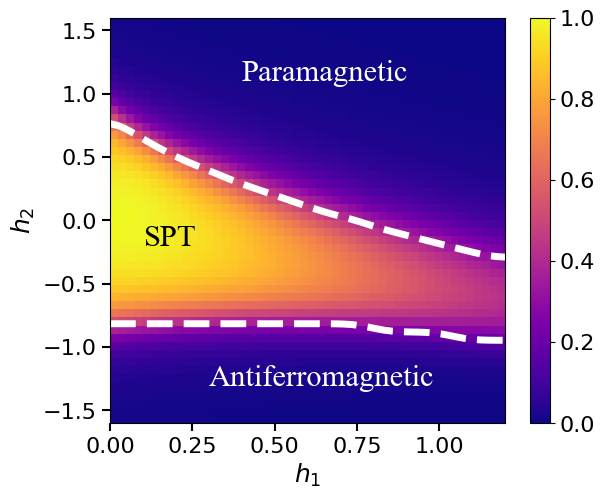

In [19]:
# --- 绘图 ---
plt.figure(figsize=(6,5))
im = plt.imshow(orders.T, 
                extent=[h1_grid[0], h1_grid[-1], h2_grid[0], h2_grid[-1]], 
                origin="lower", 
                aspect="auto", 
                cmap="plasma", 
                vmin=0, vmax=1)

# plt.colorbar(im)
cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=16)
plt.rcParams["font.family"] = "Times New Roman"
# 两条相变线
plt.plot(phase_boundary_upper[:,0], phase_boundary_upper[:,1], 'w--', linewidth=5)
plt.plot(phase_boundary_lower[:,0], phase_boundary_lower[:,1], 'w--', linewidth=5)

# 添加相区标签
plt.text(0.4, 1.1, "Paramagnetic", color="white", fontsize=22)
plt.text(0.1, -0.2, "SPT", color="black", fontsize=22)
plt.text(0.3, -1.3, "Antiferromagnetic", color="white", fontsize=22)

plt.xlabel(r"$h_1$",fontsize=18)
plt.ylabel(r"$h_2$",fontsize=18)
# plt.title("Phase diagram",fontsize=20)
plt.tight_layout()

ax = plt.gca()  # 获取当前坐标轴
major_xticks = np.linspace(h1_grid[0], h1_grid[-1], 5)  # 5个主要X刻度
major_yticks = np.linspace(h2_grid[0], h2_grid[-1], 5)  # 5个主要Y刻度
ax.tick_params(axis='both', which='major', 
               length=6, width=1.5, colors='black', labelsize=16)

plt.show()
